In [1]:
from math import e
from PBR import PBR
from Reaction import Reaction
from KineticModel import KineticModel
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from IPython.display import clear_output
import multiprocessing

In [2]:
pd.options.display.max_seq_items = 2000

In [3]:
# loading data for plotting
# Remenber: the fit was also performed on reconciled data
with open('reconciled_data_validation.pkl', 'rb') as f:
    data = pickle.load(f)
kinetic_data = data.loc[(data['CINÉTICA'] == 1.0) | (data['VALIDATION'] == 1.0)].reset_index()
kinetic_data['m_cat_kg'] = kinetic_data['m_cat_g']/1000

In [4]:
kinetic_data.head()

,index,t_h,CINÉTICA,PLOT,DESATIVAÇÃO,BM,VALIDATION,P_abs_Pa,T_R_K,F_H2_e_mol_s,...,y27,y28,y29,y30,y31,y32,y33,y34,y35,m_cat_kg
0,44,5.5,1.0,1.0,1.0,1,False,2247156.184,506.15,0.000122,...,0.002187,0.001552,0.001129,0.000776,0.000483,0.000469,0.000394,0.000335,0.000102,0.00512
1,45,6.0,1.0,1.0,1.0,1,False,2240261.427,506.15,0.000122,...,0.001923,0.001365,0.000993,0.000683,0.000425,0.000412,0.000347,0.000294,0.000090,0.00512
2,46,6.5,1.0,1.0,1.0,1,False,2233366.670,506.15,0.000122,...,0.002083,0.001478,0.001076,0.000740,0.000460,0.000447,0.000376,0.000319,0.000097,0.00512
3,47,7.0,1.0,1.0,1.0,1,False,2233366.670,506.15,0.000122,...,0.001969,0.001398,0.001017,0.000699,0.000435,0.000422,0.000355,0.000302,0.000092,0.00512
4,53,13.0,1.0,1.0,0.0,1,False,2191998.128,495.15,0.000098,...,0.004468,0.003171,0.002308,0.001586,0.000986,0.000958,0.000805,0.000684,0.000208,0.00512


In [5]:
from models_FTS.Yates            import Yates
from models_FTS.PowerLaw         import PowerLaw
from models_FTS.Botes            import Botes
from models_FTS.vanSteen         import vanSteen
from models_FTS.Ojeda            import Ojeda
from models_FTS.Mousavi          import Mousavi
from models_FTS.MousaviPLaw      import MousaviPLaw
from models_FTS.Wang             import Wang
from models_FTS.WangSimple       import WangSimple
from models_FTS.Elementary       import Elementary
from models_FTS.PowerLaw2        import PowerLaw2

In [6]:
Yates       =      Yates()
PowerLaw    =      PowerLaw()
Botes       =      Botes()
vanSteen    =      vanSteen()
Ojeda       =      Ojeda()
Mousavi     =      Mousavi()
MousaviPLaw =      MousaviPLaw()
Wang        =      Wang()
WangSimple  =      WangSimple()
Elementary  =      Elementary()
PowerLaw2 = PowerLaw2()

/home/rafael/GoogleDrive/uem/Doutorado/Ensaios/SAF/SAF_8_08_08_2025/SAF_kinetics_paper_code/Reaction.py:56: UserWarning: Something went wrong with the equilibrium constant calculation. Setting it to 1e12 (No reverse reaction). Please check your simulation. Hint: if you are fitting with isothermal = False, try setting it to True. Error: (34, 'Numerical result out of range')
  warnings.warn(f'Something went wrong with the equilibrium constant calculation. Setting it to 1e12 (No reverse reaction). Please check your simulation. Hint: if you are fitting with isothermal = False, try setting it to True. Error: {error}', UserWarning)


In [7]:
for i in range(len(kinetic_data)):
    print(f'Running simulation {i} of {len(kinetic_data) - 1}')
    clear_output(wait = True)
    F0 = kinetic_data.loc[i, 'F_H2_e_mol_s'] + kinetic_data.loc[i, 'F_CO_e_mol_s']
    
    H2_CO = kinetic_data.loc[i, '$H_2/CO$']
    x_CO = 1 / ( 1 + H2_CO )
    x_H2 = 1 - x_CO
    
    # create reactor object
    T0 = (kinetic_data.loc[i, 'T_R_K'], 'K')
    x0 = {
                      'carbon monoxide': x_CO,
                      'hydrogen' : x_H2,
                  }
    reactor = PBR(T0 = T0, 
                  P0 = (kinetic_data.loc[i, 'P_abs_Pa'], 'Pa'), 
                  x0 = x0, 
                  F0 = (F0, 'mol/s'),
                  isothermal = True, 
                  ergun = False,
                  WT = (kinetic_data.loc[i, 'm_cat_g'], 'g'), 
                  W_steps = 50,
                  U = (300, 'W/m2/K'),
                  D = (7, 'mm'),
                  Dp = (0.1725, 'mm'),
                  pellet_density = (2530, 'kg/m3'),
                  Ta = T0,
                  liquid_phase = False,
                  units = 'SI',
                  solver_method = 'BDF',
                  rtol = 1e-5, atol = 1e-7,
                  calculate_equilibrium = False,
                  equilibrium_obj_fun_tolerance = 1e-12,
                  log = True,
                 )
    
    reactor.add_model(PowerLaw)
    
    reactor.solve()
    
    sol_df = reactor.sol_dfs['PowerLaw']
    
    F_H2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'hydrogen')].value.values[-1]
    F_CO_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon monoxide')].value.values[-1]

    kinetic_data.loc[i, 'F_H2_out_model'] = F_H2_out_model
    kinetic_data.loc[i, 'F_CO_out_model'] = F_CO_out_model

Running simulation 92 of 92


In [8]:
kinetic_data['X_H2_model'] = (kinetic_data.F_H2_e_mol_s - kinetic_data.F_H2_out_model) / kinetic_data.F_H2_e_mol_s 

kinetic_data['X_CO_model'] = (kinetic_data.F_CO_e_mol_s - kinetic_data.F_CO_out_model) / kinetic_data.F_CO_e_mol_s 

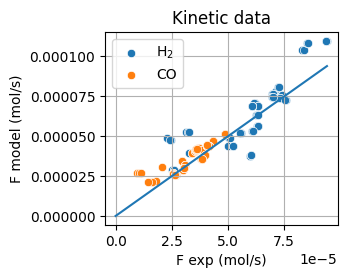

In [9]:
fig, ax = plt.subplots(figsize=(3,2.5))
max_xy = kinetic_data.F_H2_s_mol_s.max()
sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == False], 
                x = 'F_H2_s_mol_s', y = 'F_H2_out_model', label = '$\mathrm{H_2}$',
                ax = ax)
sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == False], 
                x = 'F_CO_s_mol_s', y = 'F_CO_out_model', label = 'CO',
                ax = ax)
plt.title('Kinetic data')
plt.plot((0, max_xy), (0, max_xy))
plt.ylabel('F model (mol/s)')
plt.xlabel('F exp (mol/s)')
plt.grid('both')

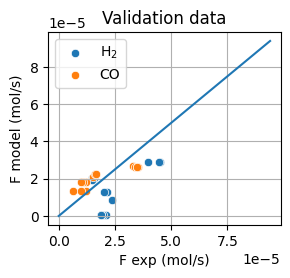

In [10]:
fig, ax = plt.subplots(figsize=(3,2.5))
max_xy = kinetic_data.F_H2_s_mol_s.max()
sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == True], 
                x = 'F_H2_s_mol_s', y = 'F_H2_out_model', label = '$\mathrm{H_2}$',
                ax = ax)
sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == True], 
                x = 'F_CO_s_mol_s', y = 'F_CO_out_model', label = 'CO',
                ax = ax)
plt.title('Validation data')
plt.plot((0, max_xy), (0, max_xy))
plt.ylabel('F model (mol/s)')
plt.xlabel('F exp (mol/s)')
plt.grid('both')

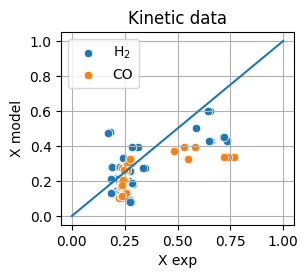

In [11]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == False], 
                x = 'X_H2', y = 'X_H2_model', label = '$\mathrm{H_2}$',
                ax = ax)
sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == False], 
                x = 'X_CO', y = 'X_CO_model', label = 'CO',
                ax = ax)
plt.title('Kinetic data')
plt.plot((0, 1), (0, 1))
plt.ylabel('X model')
plt.xlabel('X exp')
plt.grid('both')

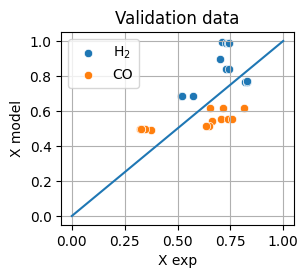

In [12]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == True], 
                x = 'X_H2', y = 'X_H2_model', label = '$\mathrm{H_2}$',
                ax = ax)
sns.scatterplot(data = kinetic_data.loc[kinetic_data.VALIDATION == True], 
                x = 'X_CO', y = 'X_CO_model', label = 'CO',
                ax = ax)
plt.title('Validation data')
plt.plot((0, 1), (0, 1))
plt.ylabel('X model')
plt.xlabel('X exp')
plt.grid('both')